# Análise Exploratória de Dado


In [0]:
import pandas as pd
import matplotlib.pyplot as plt

CATALOG = "workspace"
MIN_VOTOS_RELEVANCIA = 10000  # piso mínimo de votos para "melhores avaliações" terem significância estatística
from pyspark.sql import functions as F

## Pergunta 1
Quantos filmes e séries existem no catálogo?

In [0]:
n_filmes = (
    spark.table(f"{CATALOG}.gold.dim_title")
    .filter(F.col("title_type") == "Filme")
    .count()
)

n_series = (
    spark.table(f"{CATALOG}.gold.dim_title")
    .filter(F.col("title_type") == "Série")
    .count()
)


Total de filmes: 406,415
Total de séries: 140,646


In [0]:
print(f"O catálogo contém {n_filmes:,} filmes e {n_series:,} séries.")

O catálogo contém 406,415 filmes e 140,646 séries.


## Pergunta 2
Como os gêneros se distribuem entre filmes e séries?

> Preparação dos Dados

In [0]:
df_genero_tipo = (
    spark.table(f"{CATALOG}.gold.dim_title").alias("t")
    .join(
        spark.table(f"{CATALOG}.gold.bridge_title_genre").alias("btg"),
        "title_id"
    )
    .join(
        spark.table(f"{CATALOG}.gold.dim_genre").alias("g"),
        "genre_id"
    )
    .groupBy("title_type", "genre_name")
    .count()
    .toPandas()
)

> Distribuição dos Gêneros dos Filmes

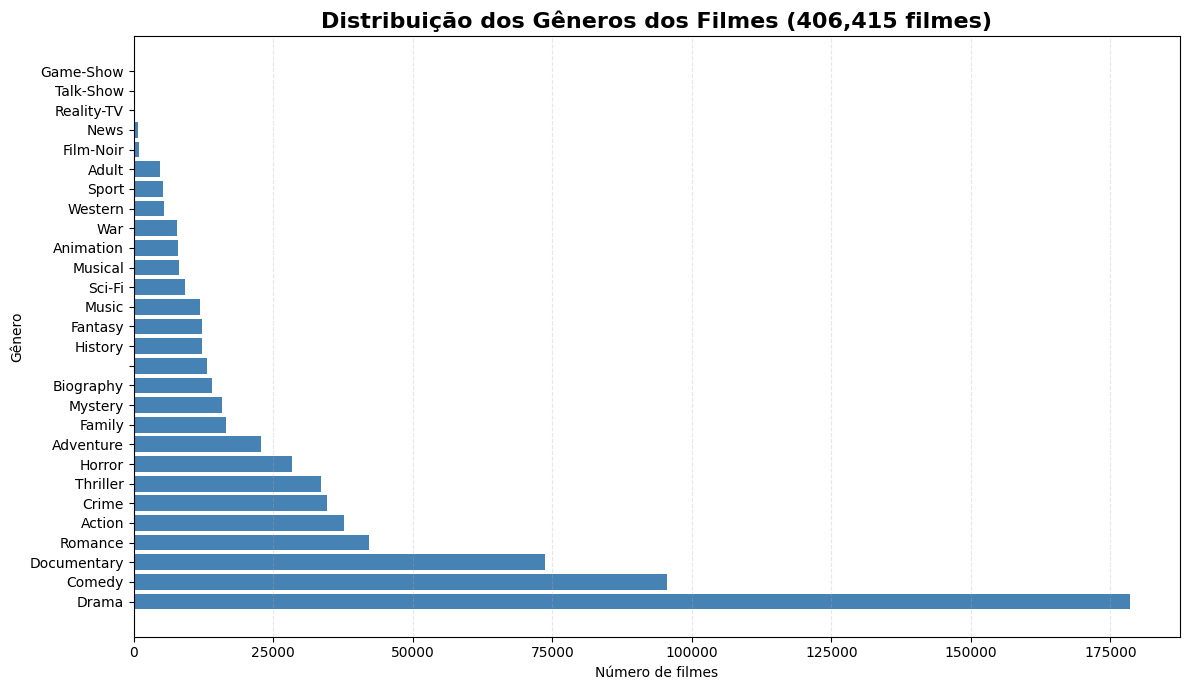

In [0]:
filmes = (
    df_genero_tipo[df_genero_tipo["title_type"] == "Filme"]
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(12,7))

plt.barh(
    filmes["genre_name"],
    filmes["count"],
    color="steelblue"
)

plt.title(
    f"Distribuição dos Gêneros dos Filmes ({n_filmes:,} filmes)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Número de filmes")
plt.ylabel("Gênero")

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

> Distribuição dos Gêneros das Séries

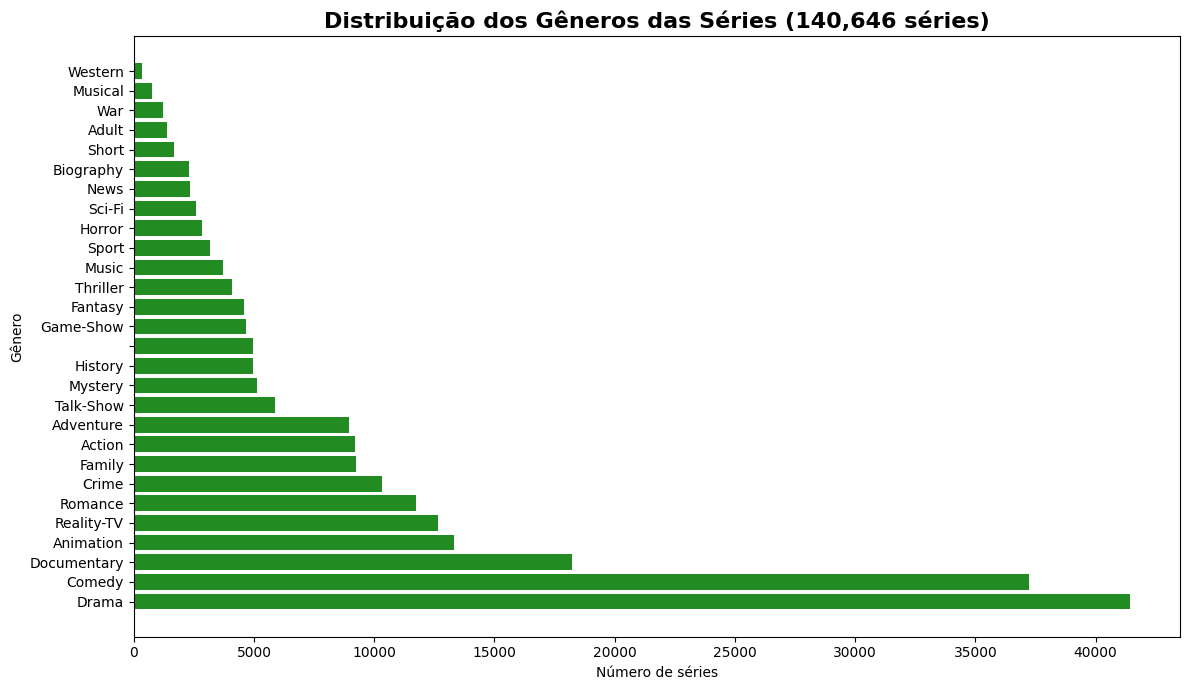

In [0]:
series = (
    df_genero_tipo[df_genero_tipo["title_type"] == "Série"]
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(12,7))

plt.barh(
    series["genre_name"],
    series["count"],
    color="forestgreen"
)

plt.title(
    f"Distribuição dos Gêneros das Séries ({n_series:,} séries)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Número de séries")
plt.ylabel("Gênero")

plt.tight_layout()
plt.show()

## Pergunta 3
Quais são os 10 filmes mais bem avaliados?

In [0]:
top_filmes = spark.sql(f"""
SELECT
    t.primary_title,
    t.start_year,
    array_join(collect_set(g.genre_name), ', ') AS generos,
    r.average_rating,
    r.num_votes
FROM {CATALOG}.gold.fact_ratings r
JOIN {CATALOG}.gold.dim_title t
    ON r.title_id = t.title_id
LEFT JOIN {CATALOG}.gold.bridge_title_genre btg
    ON t.title_id = btg.title_id
LEFT JOIN {CATALOG}.gold.dim_genre g
    ON btg.genre_id = g.genre_id
WHERE t.title_type = 'Filme'
  AND r.num_votes >= {MIN_VOTOS_RELEVANCIA}
GROUP BY
    t.primary_title,
    t.start_year,
    r.average_rating,
    r.num_votes
ORDER BY r.average_rating DESC
LIMIT 10
""").toPandas()

display(top_filmes)

primary_title,start_year,generos,average_rating,num_votes
The Shawshank Redemption,1994,Drama,9.3,3243065
The Godfather,1972,"Crime, Drama",9.2,2258949
The Chaos Class,1975,Comedy,9.1,46787
Ramayana: The Legend of Prince Rama,1993,"Action, Adventure, Animation",9.1,18113
Unpaarvayil,2025,Thriller,9.1,10043
The Dark Knight,2008,"Crime, Thriller",9.1,3231129
The Lord of the Rings: The Return of the King,2003,"Adventure, Drama, Fantasy",9.0,2195676
12 Angry Men,1957,"Crime, Drama",9.0,1004490
BLEACH: Thousand-Year Blood War - The Calamity,2026,"Animation, Fantasy",9.0,17173
Schindler's List,1993,"Biography, Drama, History",9.0,1605011


Entre os dez filmes mais bem avaliados, observa-se predominância dos gêneros Drama e Crime, com produções lançadas principalmente entre as décadas de 1970 e 2000. O filtro de pelo menos 10.000 votos garante que as avaliações reflitam o consenso de um grande número de usuários, aumentando a confiabilidade do ranking.

## Pergunta 4
Quais gêneros predominam entre os filmes mais bem avaliados?

In [0]:
top_filmes_generos = spark.sql(f"""
WITH top_filmes AS (
    SELECT
        t.title_id
    FROM {CATALOG}.gold.fact_ratings r
    JOIN {CATALOG}.gold.dim_title t
        ON r.title_id = t.title_id
    WHERE t.title_type = 'Filme'
      AND r.num_votes >= {MIN_VOTOS_RELEVANCIA}
    ORDER BY r.average_rating DESC
    LIMIT 10
)

SELECT
    g.genre_name,
    COUNT(*) AS quantidade
FROM top_filmes tf
JOIN {CATALOG}.gold.bridge_title_genre btg
    ON tf.title_id = btg.title_id
JOIN {CATALOG}.gold.dim_genre g
    ON btg.genre_id = g.genre_id
GROUP BY g.genre_name
ORDER BY quantidade DESC
""").toPandas()

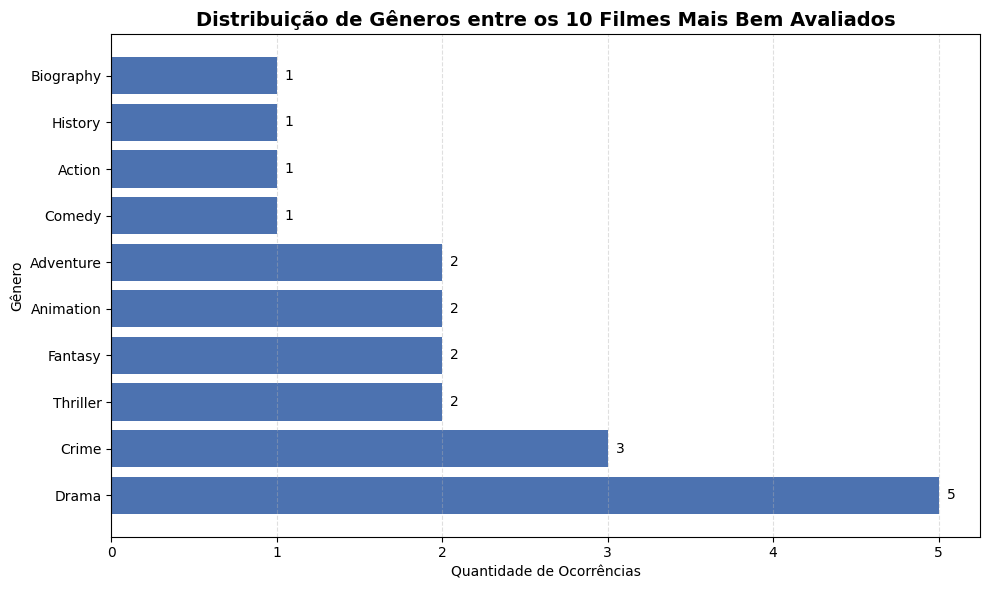

In [0]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_filmes_generos["genre_name"],
    top_filmes_generos["quantidade"],
    color="#4C72B0"
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va="center"
    )

plt.title(
    "Distribuição de Gêneros entre os 10 Filmes Mais Bem Avaliados",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Quantidade de Ocorrências")
plt.ylabel("Gênero")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Pergunta 5
Quais são as 10 séries mais bem avaliadas?

In [0]:
top_series = spark.sql(f"""
SELECT
    t.primary_title,
    t.start_year,
    array_join(collect_set(g.genre_name), ', ') AS generos,
    r.average_rating,
    r.num_votes
FROM {CATALOG}.gold.fact_ratings r
JOIN {CATALOG}.gold.dim_title t
    ON r.title_id = t.title_id
LEFT JOIN {CATALOG}.gold.bridge_title_genre btg
    ON t.title_id = btg.title_id
LEFT JOIN {CATALOG}.gold.dim_genre g
    ON btg.genre_id = g.genre_id
WHERE t.title_type = 'Série'
  AND r.num_votes >= {MIN_VOTOS_RELEVANCIA}
GROUP BY
    t.primary_title,
    t.start_year,
    r.average_rating,
    r.num_votes
ORDER BY r.average_rating DESC
LIMIT 10
""").toPandas()

display(top_series)

primary_title,start_year,generos,average_rating,num_votes
Steel Ball Run: JoJo's Bizarre Adventure,2026,"Action, Adventure, Animation",9.5,27963
Breaking Bad,2008,"Crime, Drama, Thriller",9.5,2681368
Band of Brothers,2001,"Action, Drama, History",9.4,606235
Planet Earth,2006,"Documentary, Family",9.4,236939
Planet Earth II,2016,"Documentary, Family",9.4,177016
Cosmos,1980,Documentary,9.3,53797
Avatar: The Last Airbender,2005,"Action, Adventure, Animation",9.3,456525
Chernobyl,2019,"Drama, History, Thriller",9.3,1066840
The Wire,2002,"Crime, Drama, Thriller",9.3,439886
Blue Planet II,2017,"Documentary, Family",9.3,58746


## Pergunta 6
Quais gêneros predominam entre as séries mais bem avaliadas?

In [0]:
top_series_generos = spark.sql(f"""
WITH top_series AS (
    SELECT
        t.title_id
    FROM {CATALOG}.gold.fact_ratings r
    JOIN {CATALOG}.gold.dim_title t
        ON r.title_id = t.title_id
    WHERE t.title_type = 'Série'
      AND r.num_votes >= {MIN_VOTOS_RELEVANCIA}
    ORDER BY r.average_rating DESC
    LIMIT 10
)

SELECT
    g.genre_name,
    COUNT(*) AS quantidade
FROM top_series ts
JOIN {CATALOG}.gold.bridge_title_genre btg
    ON ts.title_id = btg.title_id
JOIN {CATALOG}.gold.dim_genre g
    ON btg.genre_id = g.genre_id
GROUP BY g.genre_name
ORDER BY quantidade DESC
""").toPandas()

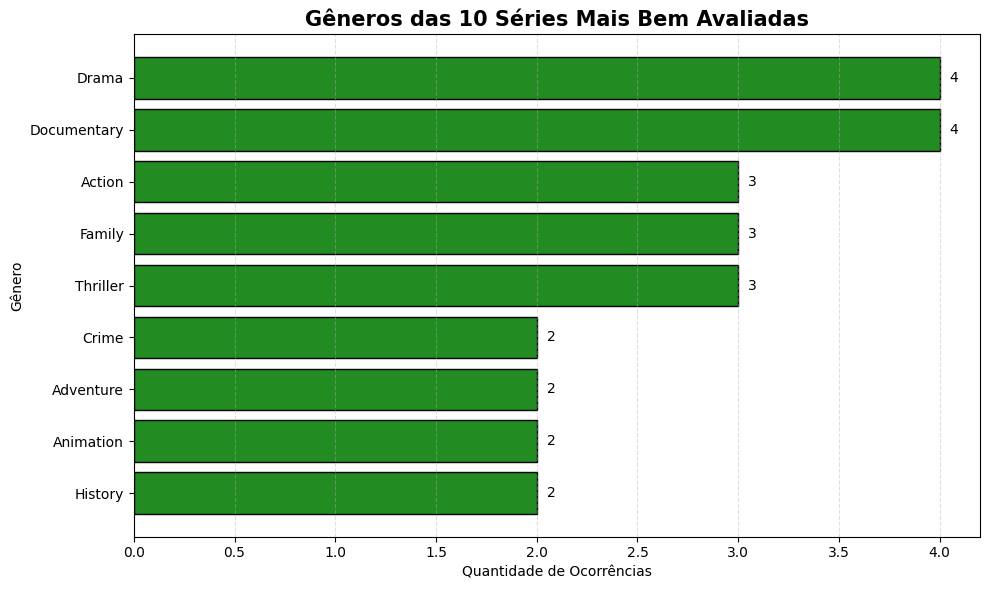

In [0]:
top_series_generos = top_series_generos.sort_values("quantidade")

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_series_generos["genre_name"],
    top_series_generos["quantidade"],
    color="forestgreen",
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va="center"
    )

plt.title(
    "Gêneros das 10 Séries Mais Bem Avaliadas",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Quantidade de Ocorrências")
plt.ylabel("Gênero")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()